# LIMPIEZA DE LAS SERIES

Para comenzar voy a tomar dos series de la pagina del indec, la primera a precios de 1993 y la segunda precios de 2004.
* Serie Vieja: https://www.indec.gob.ar/indec/web/Institucional-Indec-InformacionDeArchivo-5
* Serie Nueva: https://www.indec.gob.ar/indec/web/Nivel4-Tema-3-9-47

Luego me voy a encagar de limpiar los datos del pbi trimestral de cada serie y los voy a exportar a dos excel, en los cuales solo van a estar las fechas y los datos limpios

In [8]:
#------------------
    #BIBLIOTECAS
#------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from google.colab import files
from statsmodels.tsa.seasonal import seasonal_decompose

In [9]:
url_v = "https://github.com/martinariias/serie_empalmada_-1980-2025-/raw/main/pbi_80-05_cuadro1.xls"
url_n = "https://github.com/martinariias/serie_empalmada_-1980-2025-/raw/main/sh_oferta_demanda_desest_12_25.xls"

df_vieja = pd.read_excel(url_v)
df_nueva = pd.read_excel(url_n)

In [10]:
#------------------
#LIMPIEZA PBI VIEJO
#------------------

df_viejo = pd.read_excel(url_v, header=None)

mask_trimestres = df_viejo[0].astype(str).str.strip().isin(['I', 'II', 'III', 'IV'])
df_data = df_viejo[mask_trimestres].copy()

pbi_viejo = pd.to_numeric(df_data.iloc[:, 26].astype(str).str.replace(',',''), errors='coerce')

pbi_viejo.index = pd.period_range(start='1980Q1', periods=len(pbi_viejo), freq='Q')

df_viejo_limpio = pbi_viejo.to_frame(name='PBI')

df_viejo_limpio.index = df_viejo_limpio.index.astype(str).str.replace('Q', ' Q')
df_viejo_limpio.index.name = 'Fecha'

def formato_arg(numero):
    if pd.isna(numero):
        return numero
    num_str = f"{numero:,.2f}"
    return num_str.replace(',', 'X').replace('.', ',').replace('X', '.')

df_viejo_limpio['PBI'] = df_viejo_limpio['PBI'].apply(formato_arg)

nombre_archivo = 'PBI viejo limpio.xlsx'
df_viejo_limpio.to_excel(nombre_archivo)
files.download(nombre_archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
#------------------
#LIMPIEZA PBI NUEVO
#------------------

df_nuevo = pd.read_excel(url_n, skiprows=3)


df_nuevo['Año'] = df_nuevo['Año'].ffill()


df_nuevo = df_nuevo.dropna(subset=['Trimestre', 'PIB'])


dict_tri = {'I': 'Q1', 'II': 'Q2', 'III': 'Q3', 'IV': 'Q4'}

def formatear_fecha(row):
    anio = str(int(float(row['Año'])))
    tri_raw = str(row['Trimestre']).strip()
    tri_fix = dict_tri.get(tri_raw, tri_raw)
    return f"{anio} {tri_fix}"

df_nuevo['Fecha'] = df_nuevo.apply(formatear_fecha, axis=1)


def formato_argentino(valor):
    if pd.isna(valor): return ""
    return f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

df_nuevo['PBI_Texto'] = df_nuevo['PIB'].apply(formato_argentino)


df_final = df_nuevo[['Fecha', 'PBI_Texto']].copy()
df_final.columns = ['Fecha', 'PBI']


nombre_salida = 'PBI nuevo limpio.xlsx'
df_final.to_excel(nombre_salida, index=False)

files.download(nombre_salida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# EMPALME DE LAS SERIES

Con las series ya limpias, el siguiente paso es empalmarlas con el Método de Retrapolación por Coeficiente de Enlace (Splicing), es decir, calculo un factor de empalme, dado por el cociente entre ambas series y luego multiplico ese factor por la serie vieja, tal que:

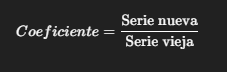

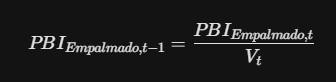

In [12]:
#------------------
      #EMPALME
#------------------
def arg_to_float(valor):
    if pd.isna(valor): return valor
    if isinstance(valor, (int, float)): return valor
    return float(str(valor).replace('.', '').replace(',', '.'))

def formato_arg(numero):
    if pd.isna(numero): return numero
    return f"{numero:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

df_viejo = pd.read_excel('/content/PBI viejo limpio.xlsx', index_col=0)
df_nuevo = pd.read_excel('/content/PBI nuevo limpio.xlsx', index_col=0)

df_viejo.index = df_viejo.index.astype(str)
df_nuevo.index = df_nuevo.index.astype(str)

df_viejo['PBI'] = df_viejo['PBI'].apply(arg_to_float)
df_nuevo['PBI'] = df_nuevo['PBI'].apply(arg_to_float)

suma_viejo_2004 = df_viejo[df_viejo.index.str.contains('2004')]['PBI'].sum()
suma_nuevo_2004 = df_nuevo[df_nuevo.index.str.contains('2004')]['PBI'].sum()

factor_empalme = suma_nuevo_2004 / suma_viejo_2004

df_historia = df_viejo[df_viejo.index.str[:4] < '2004'].copy()
df_historia['PBI'] = df_historia['PBI'] * factor_empalme

df_empalmado = pd.concat([df_historia, df_nuevo])

df_empalmado['PBI'] = df_empalmado['PBI'].apply(formato_arg)

nombre_salida = 'PBI Serie Empalmada (1980-2025).xlsx'
df_empalmado.to_excel(nombre_salida)
files.download(nombre_salida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# DESESTACIONALIZACION Y GRAFICO

El ultimo paso es la desestacionalizacion de la series, es decir, quitar los efectos de las distintas epocas del año y como en estas la produccion es especial.
Luego de ese proceso estadistico, grafico el resultado.

In [13]:
#------------------
#DESESTACIONALIZACION
#------------------

# 1. Función de conversión (la de siempre)
def arg_to_float(val):
    try:
        return float(str(val).replace('.', '').replace(',', '.'))
    except:
        return np.nan

# 2. CARGAR SERIES
# Serie vieja (1980-2004) - Sin desestacionalizar
df_viejo = pd.read_excel('/content/PBI viejo limpio.xlsx') # Cambiá al nombre de tu archivo viejo
df_viejo['PBI_num'] = df_viejo['PBI'].apply(arg_to_float)

# Serie nueva (2004-2025) - Ya desestacionalizada por INDEC
df_nuevo = pd.read_excel('/content/PBI nuevo limpio.xlsx')
df_nuevo['PBI_num'] = df_nuevo['PBI'].apply(arg_to_float)

# 3. DESESTACIONALIZAR SOLO LA SERIE VIEJA
# Usamos el modelo multiplicativo para limpiar los años 80 y 90
res = seasonal_decompose(df_viejo['PBI_num'], model='multiplicative', period=4)
df_viejo['PBI_desest'] = res.trend * res.resid # Serie limpia de la vieja

# 4. EMPALME (SPLICING)
# Calculamos el factor de enlace en el año 2004 (donde se cruzan)
# Promedio de la nueva en 2004 / Promedio de la vieja en 2004
pbi_n_2004 = df_nuevo[df_nuevo['Fecha'].str.contains('2004')]['PBI_num'].mean()
pbi_v_2004 = df_viejo[df_viejo['Fecha'].str.contains('2004')]['PBI_num'].mean()
factor = pbi_n_2004 / pbi_v_2004

# Aplicamos el factor a la serie vieja desestacionalizada
df_viejo['PBI_final'] = df_viejo['PBI_desest'] * factor
df_nuevo['PBI_final'] = df_nuevo['PBI_num'] # La nueva ya está lista

# 5. UNIR TODO
df_total = pd.concat([df_viejo[df_viejo['Fecha'] < '2004 Q1'], df_nuevo])


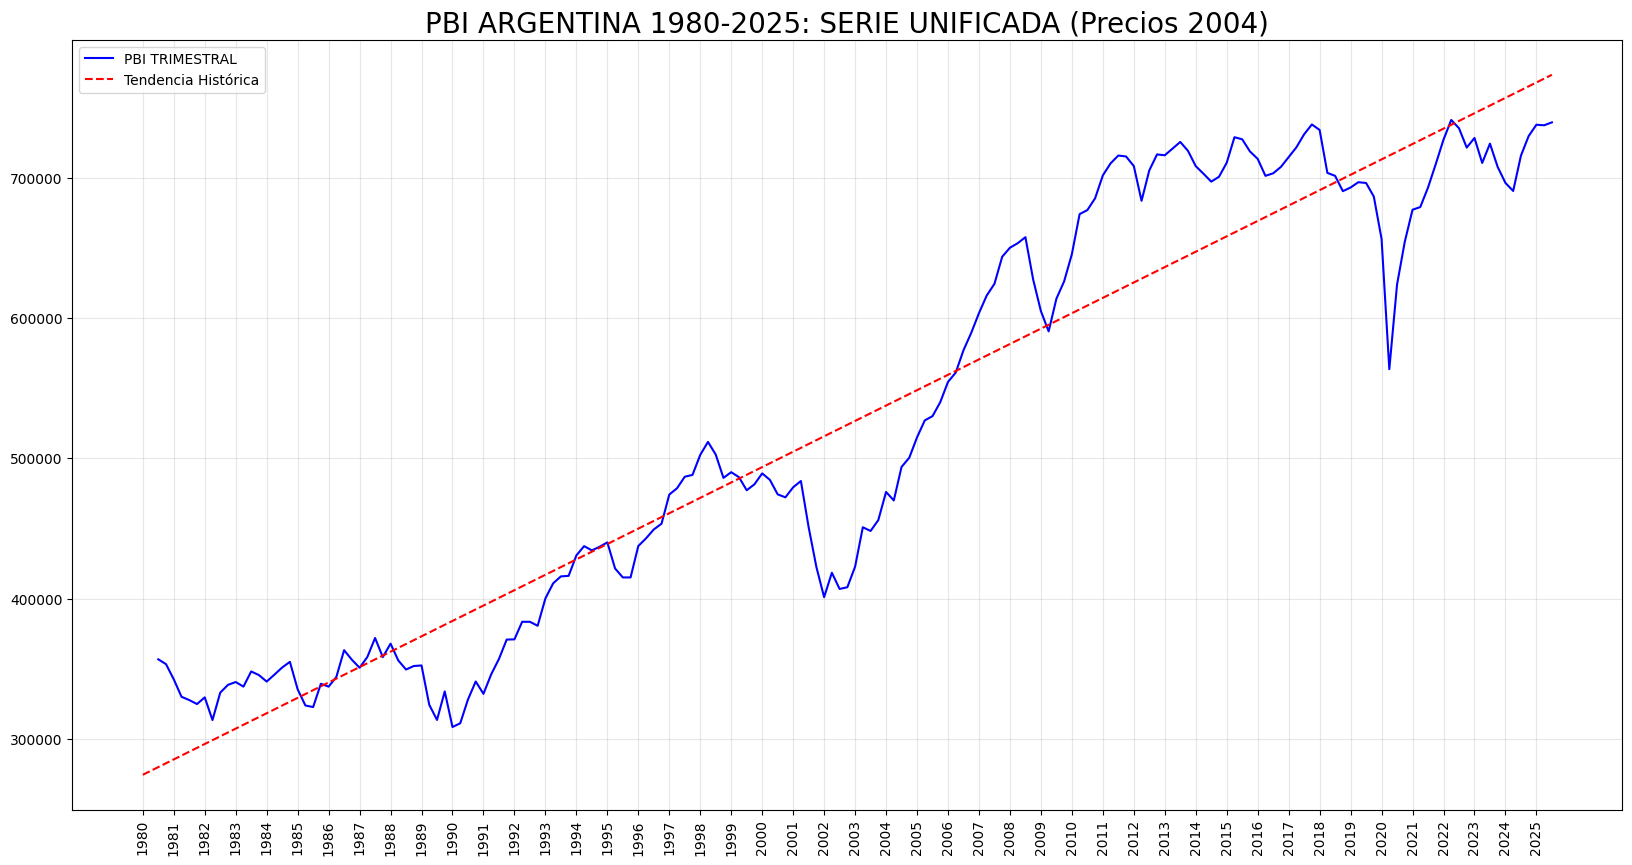

In [14]:
#------------------
#GRAFICO DE LA SERIE
#------------------
plt.figure(figsize=(20, 10))
x = np.arange(len(df_total))
y = df_total['PBI_final'].values

plt.plot(x, y, color='blue', label='PBI TRIMESTRAL')

# Tendencia
mask = ~np.isnan(y)
coef = np.polyfit(x[mask], y[mask], 1)
plt.plot(x, np.polyval(coef, x), color='red', linestyle='--', label='Tendencia Histórica')

plt.xticks(ticks=np.arange(0, len(df_total), 4),
           labels=[str(f)[:4] for f in df_total['Fecha'].values[::4]], rotation=90)

plt.title('PBI ARGENTINA 1980-2025: SERIE UNIFICADA (Precios 2004)', fontsize=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()